In [12]:
!conda install -y bedtools bioawk samtools

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [13]:
%cd ~/binfo1-work/

/home/jobor/binfo1-work


In [14]:
!grep '	start_codon	.*	+	.*transcript_support_level "1"' gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-start.gtf
!head gencode-start.gtf

grep: ../binfo1-datapack1/gencode.gtf: No such file or directory


In [15]:
!grep '	exon	.*	+	' gencode.gtf | \
 sed -e 's/	[^	]*transcript_id "\([^"]*\)".*$/	\1/g' > gencode-plusexon.gtf
!head gencode-plusexon.gtf

grep: ../binfo1-datapack1/gencode.gtf: No such file or directory


In [16]:
!bedtools intersect -a gencode-start.gtf -b gencode-plusexon.gtf -wa -wb | \
 awk -F'	' -v OFS='	' '$9 == $18 { print $10, $13-1, $14, $18, $4-1, $16; }' | \
 sort -k1,1 -k2,3n -k4,4 > gencode-exons-containing-startcodon.bed
!head gencode-exons-containing-startcodon.bed; tail gencode-exons-containing-startcodon.bed

In [17]:
!(samtools view -H RPF-siLuc.bam; \
  samtools view -F20 RPF-siLuc.bam | \
  bioawk -c sam '{ if (length($seq) >= 25) print $0; }') | \
 samtools view -b -o filtered-RPF-siLuc.bam

In [18]:
!ls -al *RPF-siLuc.bam

-rw-r--r-- 1 jobor jobor 1055123479 Apr 27 15:05 RPF-siLuc.bam
-rw-r--r-- 1 jobor jobor  554373658 May  7 14:22 filtered-RPF-siLuc.bam


In [19]:
!bedtools genomecov -ibam filtered-RPF-siLuc.bam -bg -5 > fivepcounts-RPF-siLuc.bed
!head fivepcounts-RPF-siLuc.bed

chr1	3176534	3176535	1
chr1	3196256	3196257	1
chr1	3221526	3221527	1
chr1	3221542	3221543	2
chr1	3221545	3221546	3
chr1	3221546	3221547	2
chr1	3221548	3221550	1
chr1	3221571	3221572	1
chr1	3221897	3221898	1
chr1	3221994	3221995	1


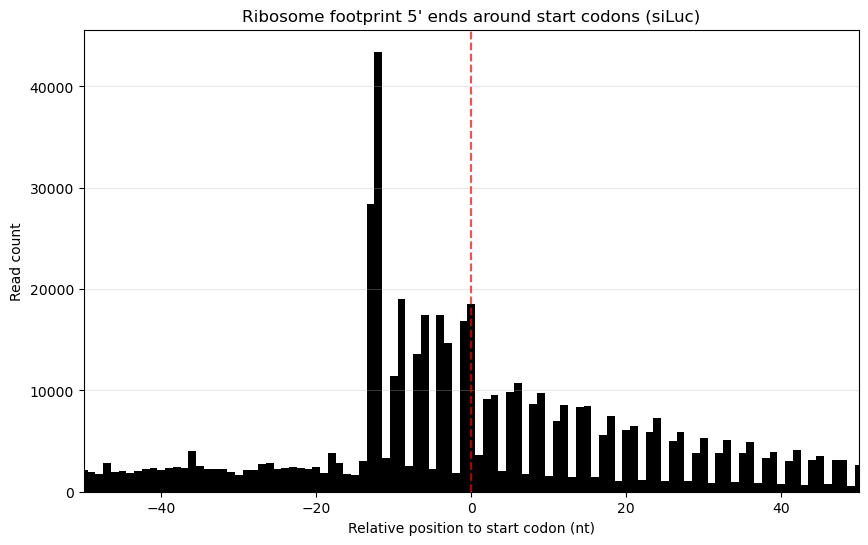

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from bisect import bisect_left

start_codons = defaultdict(list)
with open('gencode-start.gtf', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 9:
            chrom = parts[0]
            start_pos = int(parts[3]) - 1
            start_codons[chrom].append(start_pos)


start_codons_sorted = {k: sorted(list(set(v))) for k, v in start_codons.items()}

counts = Counter()
with open('fivepcounts-RPF-siLuc.bed', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 4: continue
        chrom = parts[0]
        pos = int(parts[1])
        count = int(parts[3])
        
        if chrom in start_codons_sorted:
            scs = start_codons_sorted[chrom]
            idx = bisect_left(scs, pos)
            for i in [idx-1, idx]:
                if 0 <= i < len(scs):
                    dist = pos - scs[i]
                    if -50 <= dist <= 50:
                        counts[dist] += count

df = pd.DataFrame(list(counts.items()), columns=['Position', 'Count'])
df = df.sort_values('Position')

plt.figure(figsize=(10, 6))
plt.bar(df['Position'], df['Count'], color='black', width=1)
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.title("Ribosome footprint 5' ends around start codons (siLuc)")
plt.xlabel("Relative position to start codon (nt)")
plt.ylabel("Read count")
plt.xlim(-50, 50)
plt.grid(axis='y', alpha=0.3)
plt.show()
